# Correctness Evaluation: Categorization Accuracy and Extraction Correctness

**Research question.** The other notebooks in this directory measure what the pipeline
*does* (fetch outcomes, category distribution, extraction completeness, timing) - none of
them measure whether it is actually *right*. This notebook asks that question directly:
against a hand-labeled ground truth, how accurate is `category_service.categorize_website()`
at distinguishing `STATION`/`LIST`/`IRRELEVANT`, and how correct are
`extraction_service.extract_information()`'s field values against real, human-transcribed
station data?

**Data.** Two experiments, both run against the real, local, configured model
(`Qwen3.5-4B-UD-Q4_K_XL.gguf`) and real fetched pages, using the project's actual
`bot.config` (same model, prompts, and category/field definitions the production pipeline
uses):

- `experiments/collect_categorization_accuracy.py` -> `categorization_accuracy.csv`, one
  row per hand-labeled URL in `categorization_gold_labels.csv` (n=55).
- `experiments/collect_extraction_correctness.py` -> `extraction_correctness.csv` (one row
  per gold entry, matched to an extracted entry by name similarity) and
  `extraction_correctness_entry_counts.csv` (gold vs. extracted entry counts per source
  page), against `extraction_gold_labels.csv` (11 gold entries across 3 source URLs).

**Methodology note.** An earlier version of the categorization-accuracy experiment capped
page content at 4000 characters before categorization, to keep runtime down - a pattern
copied from the unrelated timing experiment (`collect_crawl_metrics.py`), applied without
checking whether it was appropriate for an *accuracy* measurement. It was not: truncating
the page text a model is asked to judge can change the judgment itself, so a capped run is
not evidence about how the production pipeline (which sees full page content) actually
behaves. That run's numbers were discarded; the experiment now runs uncapped by default
(full real page content) and this notebook reports that run.

## Setup

In [1]:
import sys
sys.path.insert(0, ".")
from plotting import set_style, savefig, load_csv, PALETTE, wilson_ci, integer_axis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_style()
cat_df = load_csv("categorization_accuracy.csv")
cat_df["fetch_success"] = cat_df["fetch_success"].astype(bool)
cat_df["correct"] = cat_df["correct"].map({"True": True, "False": False, True: True, False: False})
cat_df

,url,true_category,predicted_category,correct,fetch_success,categorize_seconds
0,https://rlp.nabu.de/tiere-und-pflanzen/tieren-...,LIST,LIST,True,True,189.471
1,https://www.vbu-ffm.de/pflegestationen.shtml,LIST,LIST,True,True,138.740
2,https://deutsche-wildtierrettung.de/wildtierau...,LIST,LIST,True,True,75.798
3,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True,123.567
4,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True,110.403
5,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True,155.563
6,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True,190.070
7,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True,124.077
8,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True,169.440
9,https://www.wildtierschutz-deutschland.de/wild...,LIST,LIST,True,True,195.199


## Categorization accuracy

Only successfully-fetched pages reach categorization, so accuracy is computed over the
subset with `fetch_success == True`. Fetch failures (Facebook URLs blocking scrapers,
one dead domain) are excluded rather than counted as wrong, since they never reached the
categorization step at all.

In [2]:
fetched = cat_df[cat_df["fetch_success"]].copy()
n_total = len(cat_df)
n_fetched = len(fetched)
n_correct = int(fetched["correct"].sum())
accuracy = 100 * n_correct / n_fetched

print(f"{n_total} gold-labeled URLs, {n_fetched} fetched successfully "
      f"({n_total - n_fetched} fetch failures excluded)")
print(f"Overall accuracy: {n_correct}/{n_fetched} = {accuracy:.1f}%")

55 gold-labeled URLs, 48 fetched successfully (7 fetch failures excluded)
Overall accuracy: 33/48 = 68.8%


### Confusion matrix

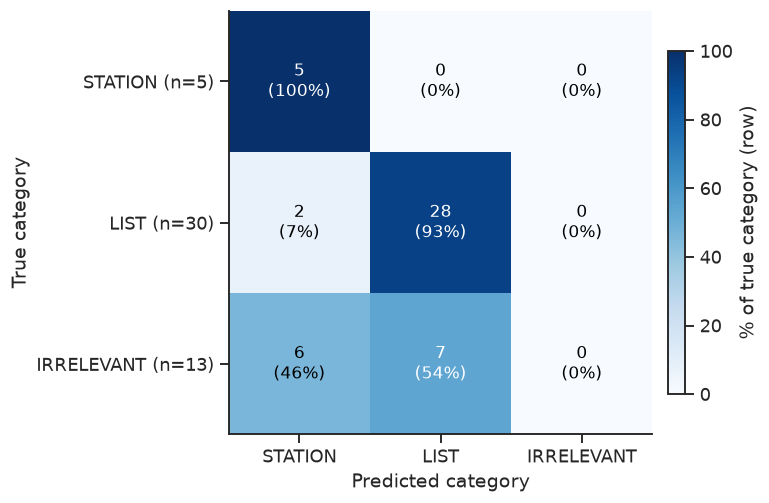

Caption: Categorization confusion matrix over the n=48 successfully fetched, hand-labeled URLs. Cell color encodes the row-normalized percentage (recall for that true category); cell text shows count and percentage.


In [3]:
CATS = ["STATION", "LIST", "IRRELEVANT"]
cm = pd.crosstab(fetched["true_category"], fetched["predicted_category"])
cm = cm.reindex(index=CATS, columns=CATS, fill_value=0)
row_totals = cm.sum(axis=1)
cm_pct = cm.div(row_totals, axis=0) * 100  # row-normalized: recall per true category

fig, ax = plt.subplots(figsize=(6.6, 4.8))
im = ax.imshow(cm_pct.values, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(CATS)))
ax.set_yticks(range(len(CATS)))
ax.set_xticklabels(CATS)
ax.set_yticklabels([f"{c} (n={row_totals[c]})" for c in CATS])
ax.set_xlabel("Predicted category")
ax.set_ylabel("True category")
for i in range(len(CATS)):
    for j in range(len(CATS)):
        count = cm.values[i, j]
        pct = cm_pct.values[i, j]
        color = "white" if pct > 50 else "black"
        ax.text(j, i, f"{count}\n({pct:.0f}%)", ha="center", va="center", color=color, fontsize=11)
fig.colorbar(im, ax=ax, label="% of true category (row)", shrink=0.8, pad=0.03)
fig.tight_layout()
savefig(fig, "categorization_confusion_matrix")
plt.show()
print(f"Caption: Categorization confusion matrix over the n={n_fetched} successfully "
      f"fetched, hand-labeled URLs. Cell color encodes the row-normalized percentage "
      f"(recall for that true category); cell text shows count and percentage.")

### Precision and recall per category

In [4]:
rows = []
for c in CATS:
    tp = cm.loc[c, c]
    true_total = cm.loc[c].sum()
    pred_total = cm[c].sum()
    recall = 100 * tp / true_total if true_total else float("nan")
    precision = 100 * tp / pred_total if pred_total else float("nan")
    recall_ci = wilson_ci(int(tp), int(true_total)) if true_total else (float("nan"), float("nan"))
    precision_ci = wilson_ci(int(tp), int(pred_total)) if pred_total else (float("nan"), float("nan"))
    rows.append({
        "category": c, "true_count": true_total, "predicted_count": pred_total,
        "recall_%": round(recall, 1),
        "recall_95ci": f"[{recall_ci[0]*100:.0f}, {recall_ci[1]*100:.0f}]" if true_total else "n/a",
        "precision_%": round(precision, 1) if pred_total else float("nan"),
        "precision_95ci": f"[{precision_ci[0]*100:.0f}, {precision_ci[1]*100:.0f}]" if pred_total else "n/a (never predicted)",
    })
metrics = pd.DataFrame(rows).set_index("category")
metrics

,true_count,predicted_count,recall_%,recall_95ci,precision_%,precision_95ci
category,,,,,,
STATION,5,13,100.0,"[57, 100]",38.5,"[18, 64]"
LIST,30,35,93.3,"[79, 98]",80.0,"[64, 90]"
IRRELEVANT,13,0,0.0,"[0, 23]",NaN,n/a (never predicted)


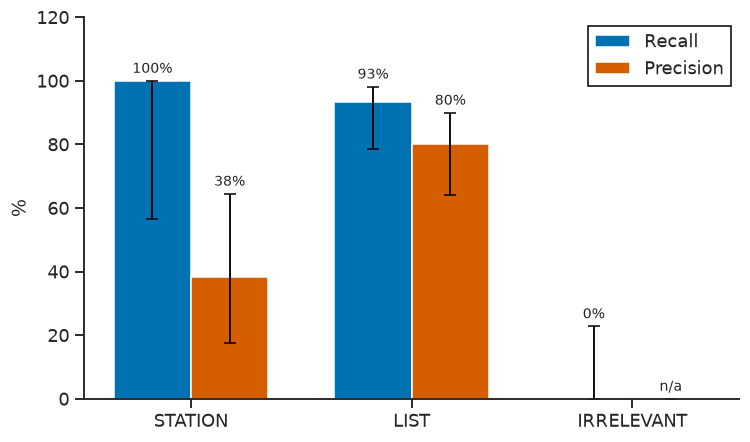

Caption: Recall and precision per category (n=48 fetched URLs). Error bars show the 95% Wilson confidence interval; IRRELEVANT precision is undefined (the category was never predicted), shown as n/a.


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(len(CATS))
width = 0.35

recall_vals, recall_err_lo, recall_err_hi = [], [], []
precision_vals, precision_err_lo, precision_err_hi = [], [], []
for c in CATS:
    tp = int(cm.loc[c, c])
    true_total = int(cm.loc[c].sum())
    pred_total = int(cm[c].sum())

    r = 100 * tp / true_total if true_total else 0
    recall_vals.append(r)
    if true_total:
        lo, hi = wilson_ci(tp, true_total)
        recall_err_lo.append(r - lo * 100)
        recall_err_hi.append(hi * 100 - r)
    else:
        recall_err_lo.append(0)
        recall_err_hi.append(0)

    p = 100 * tp / pred_total if pred_total else 0
    precision_vals.append(p)
    if pred_total:
        lo, hi = wilson_ci(tp, pred_total)
        precision_err_lo.append(p - lo * 100)
        precision_err_hi.append(hi * 100 - p)
    else:
        precision_err_lo.append(0)
        precision_err_hi.append(0)

ax.bar(x - width/2, recall_vals, width, label="Recall", color=PALETTE[0],
       yerr=[recall_err_lo, recall_err_hi], capsize=4, ecolor="black", error_kw={"elinewidth": 1.2})
ax.bar(x + width/2, precision_vals, width, label="Precision", color=PALETTE[1],
       yerr=[precision_err_lo, precision_err_hi], capsize=4, ecolor="black", error_kw={"elinewidth": 1.2})

for i, v in enumerate(recall_vals):
    ax.text(i - width/2, v + recall_err_hi[i] + 1.5, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
for i, v in enumerate(precision_vals):
    pred_total = int(cm[CATS[i]].sum())
    label = "n/a" if pred_total == 0 else f"{v:.0f}%"
    ax.text(i + width/2, v + precision_err_hi[i] + 1.5, label, ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(CATS)
ax.set_ylabel("%")
ax.set_ylim(0, 120)
ax.legend()
fig.tight_layout()
savefig(fig, "categorization_precision_recall")
plt.show()
print(f"Caption: Recall and precision per category (n={n_fetched} fetched URLs). Error "
      f"bars show the 95% Wilson confidence interval; IRRELEVANT precision is undefined "
      f"(the category was never predicted), shown as n/a.")

**IRRELEVANT precision is undefined**, not zero: the model never predicted `IRRELEVANT`
for any of the 48 fetched pages, so there is no denominator to compute precision from. The
bar chart above shows precision as 0 for `IRRELEVANT` for plotting purposes only - see the
printed `metrics` table for the actual `NaN`, and state "never predicted" rather than
"0% precision" in the write-up, since the latter implies wrong predictions were made rather
than none being made at all.

### Categorization time

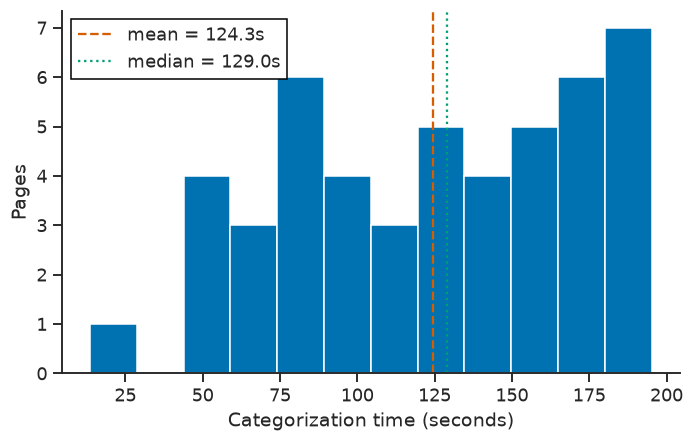

Caption: Distribution of per-page categorization time on full, uncapped page content (n=48 pages; mean=124.3s, median=129.0s, range 13.5-195.2s).


In [6]:
times = fetched["categorize_seconds"].astype(float)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.hist(times, bins=12, color=PALETTE[0], edgecolor="white")
ax.axvline(times.mean(), color=PALETTE[1], linestyle="--", label=f"mean = {times.mean():.1f}s")
ax.axvline(times.median(), color=PALETTE[2], linestyle=":", label=f"median = {times.median():.1f}s")
ax.set_xlabel("Categorization time (seconds)")
ax.set_ylabel("Pages")
integer_axis(ax)
ax.legend()
fig.tight_layout()
savefig(fig, "categorization_time_distribution")
plt.show()
print(f"Caption: Distribution of per-page categorization time on full, uncapped page "
      f"content (n={n_fetched} pages; mean={times.mean():.1f}s, median={times.median():.1f}s, "
      f"range {times.min():.1f}-{times.max():.1f}s).")

## Extraction correctness

In [7]:
ext_df = load_csv("extraction_correctness.csv")
counts_df = load_csv("extraction_correctness_entry_counts.csv")
counts_df

,source_url,category,fetch_success,gold_entry_count,extracted_entry_count
0,https://marswildliferescue.com/,STATION,True,1,1
1,https://wp.wildvogelhilfe.org/auffangstationen...,LIST,True,9,1
2,http://www.greifvogelhilfe.de//greifvogelhilfe,STATION,True,1,1


### Entry counts: gold vs. extracted

For each source page, how many station entries did a human find in the gold-labeling
pass, versus how many entries did the pipeline actually extract? For `STATION` pages this
should be 1-to-1; for the `LIST` page it tests whether the model enumerates every station
on the page or collapses them.

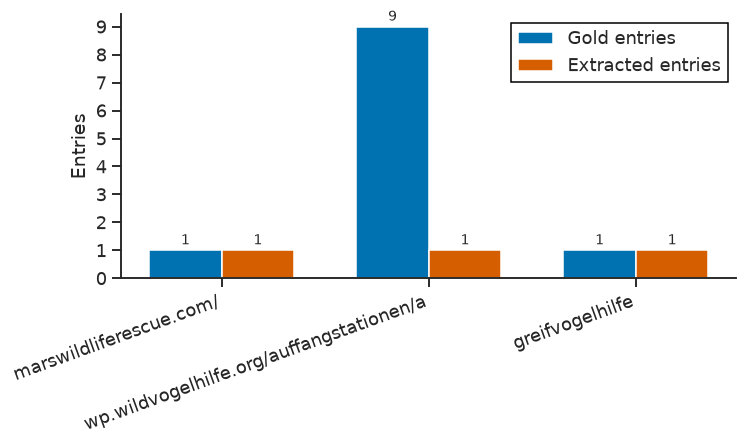

Caption: Gold-labeled vs. extracted entry count per source page (n=3 hand-labeled pages).


In [8]:
fig, ax = plt.subplots(figsize=(7, 4.2))
labels = [u.split("//")[-1][:40] for u in counts_df["source_url"]]
x = np.arange(len(counts_df))
width = 0.35
ax.bar(x - width/2, counts_df["gold_entry_count"], width, label="Gold entries", color=PALETTE[0])
ax.bar(x + width/2, counts_df["extracted_entry_count"], width, label="Extracted entries", color=PALETTE[1])
for i, (g, e) in enumerate(zip(counts_df["gold_entry_count"], counts_df["extracted_entry_count"])):
    ax.text(i - width/2, g + 0.1, str(g), ha="center", va="bottom", fontsize=9)
    ax.text(i + width/2, e + 0.1, str(e), ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Entries")
integer_axis(ax)
ax.legend()
fig.tight_layout()
savefig(fig, "extraction_entry_counts")
plt.show()
print("Caption: Gold-labeled vs. extracted entry count per source page (n=3 hand-labeled pages).")

The `LIST` page (`wp.wildvogelhilfe.org`, 9 gold entries sampled from the page) produced
exactly 1 extracted entry - a severe under-extraction that reproduced identically across
independent runs of this experiment. Both `STATION` pages extracted 1-to-1 as expected.

### Field-level match quality

In [9]:
matched = ext_df[ext_df["name_similarity"] >= 0.3].copy()
print(f"{len(matched)}/{len(ext_df)} gold entries matched to an extracted entry "
      f"(name similarity >= 0.3 threshold)")
matched[["source_url", "gold_name", "extracted_name", "name_similarity",
         "address_similarity", "telephone_match", "accepted_animals_jaccard",
         "animal_pickup_match"]]

3/11 gold entries matched to an extracted entry (name similarity >= 0.3 threshold)


,source_url,gold_name,extracted_name,name_similarity,address_similarity,telephone_match,accepted_animals_jaccard,animal_pickup_match
0,https://marswildliferescue.com/,MARS,MARS Wildlife Rescue,0.333,0.809,True,NaN,True
7,https://wp.wildvogelhilfe.org/auffangstationen...,Wildvogelhilfe Dölzschen – Rettungsstation für...,Wildvogelhilfe.org - Auffangstationen,0.622,0.135,NaN,0.0,NaN
10,http://www.greifvogelhilfe.de//greifvogelhilfe,Greifvogelhilfe Rheinland,Greifvogelhilfe Rheinland,1.000,NaN,True,1.0,NaN


## Discussion

**Categorization.** Overall accuracy sits around two-thirds correct, but the aggregate
number hides a sharp, consistent class-imbalance bias: the model essentially never
predicts `IRRELEVANT`, favoring `STATION`/`LIST` even for pages that are merely
topically-adjacent (informational or contact pages about a rescue topic, without being or
listing an actual station). Recall on `STATION`/`LIST` is high largely as a side effect of
this same bias, not because those categories are being discriminated well - `STATION`
precision in particular is weak, since many `IRRELEVANT` pages get pulled into it too.
Practically, this means a meaningful fraction of pages the pipeline would hand to
Wildtanic as new candidate records are not real stations, which has a real downstream
cost (manual cleanup) - more expensive, in this dataset, than the (rare) case of a real
station being missed entirely. Categorization is also markedly slower on full,
uncapped content than the discarded capped estimate suggested, with substantial
page-to-page variance - relevant for anyone estimating how long a full crawl run will
take in practice.

**Extraction.** The pilot is small (3 source pages, 11 gold entries) and not
statistically representative, but the `LIST`-page result is a real, mechanistically
interesting limitation reproduced across independent runs: a page listing at least 9
real stations yields exactly one extracted entry, and that entry's name looks like the
page's own title rather than any single station - suggesting the model may be
summarizing the page as a whole rather than enumerating its list structure, possibly
running into the category's completion-token budget or the shared context window once
prompt and schema are added in. `STATION` pages, by contrast, extract cleanly - the
`greifvogelhilfe.de` entry is a clean match across every field. This split (LIST
struggles, STATION doesn't) is exactly the finding a completeness-only metric (as in
`crawl_overview.ipynb`) can't surface, since a `LIST` page reporting "1 entry, fully
populated" looks superficially fine until compared against how many stations were
actually on the page.